In [ ]:
!pip install nbformat

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. Load dataset from seaborn ──────────────────────────────────────────────
df = sns.load_dataset('titanic')
df.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False


In [44]:
# ── 2. Keep useful columns & drop nulls ───────────────────────────────────────
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
df.dropna(inplace=True)
df.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.25,S


In [45]:
# ── 3. Encode categorical columns (same as get_dummies in original) ────────────
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [46]:
# ── 4. Split X and y ──────────────────────────────────────────────────────────
X = df.drop(columns=['survived'])
y = df['survived'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [47]:
# ── 5. Scale features ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf  = scaler.transform(X_test)

In [48]:
# ── 6. Build Neural Network (same architecture) ───────────────────────────────
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(11, activation='sigmoid', input_dim=X_train_trf.shape[1]))
model.add(Dense(11, activation='sigmoid'))
model.add(Dense(1,  activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
# ── 7. Compile & Train ────────────────────────────────────────────────────────
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_trf, y_train,
                    batch_size=50,
                    epochs=100,
                    verbose=1,
                    validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6246 - loss: 0.6754 - val_accuracy: 0.6316 - val_loss: 0.6690
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6059 - loss: 0.6797 - val_accuracy: 0.6316 - val_loss: 0.6672
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5614 - loss: 0.6980 - val_accuracy: 0.6316 - val_loss: 0.6654
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6139 - loss: 0.6724 - val_accuracy: 0.6316 - val_loss: 0.6629
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5762 - loss: 0.6853 - val_accuracy: 0.6316 - val_loss: 0.6607
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6058 - loss: 0.6704 - val_accuracy: 0.6316 - val_loss: 0.6586
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6006 - loss: 0.6711 - val_accuracy: 0.6316 - val_loss: 0.6560
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6104 - loss: 0.6639 - val_accuracy: 0.6

In [50]:
# ── 8. Predict & Evaluate ─────────────────────────────────────────────────────
y_pred = model.predict(X_test_trf)
y_pred = (y_pred > 0.5).astype(int).flatten()   # threshold at 0.5 (better than argmax for binary)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step
Accuracy: 0.8111888111888111


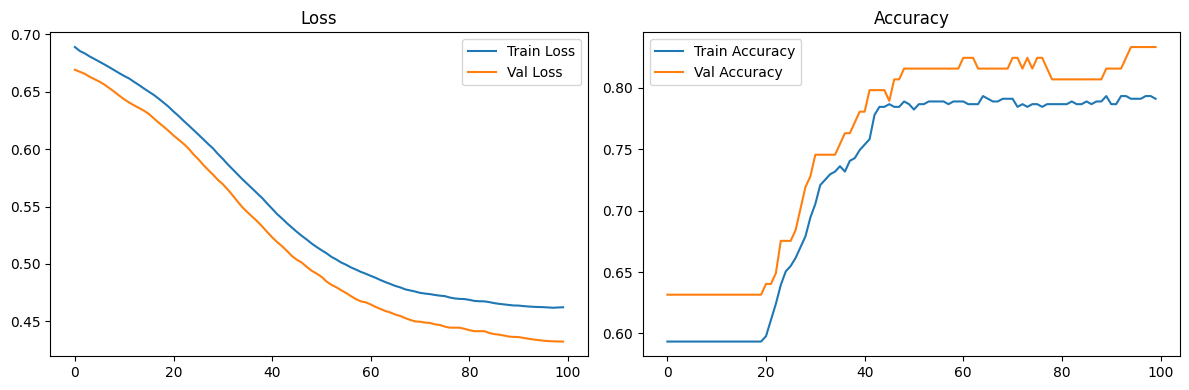

In [51]:
# ── 9. Plot Loss & Accuracy curves ────────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()